# Fuzzy Search System for Athletes Dataset



## Project Overview
This project implements a fuzzy search system for an athletes dataset using Levenshtein Distance. We aim to:
1. **Theory:** Build a custom Levenshtein Distance algorithm.
2. **Implementation:** Code it from scratch with optimization.
3. **Application:** Search athlete names with typo tolerance, returning detailed data.
4. **Comparison:** Benchmark against Rapidfuzz for performance.
- **Dataset** [Here](https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results?resource=download).

## Imports
We import libraries for data handling, timing, visualization, and Rapidfuzz.

In [1]:
import pandas as pd
import time
import matplotlib.pyplot as plt
from rapidfuzz.distance import Levenshtein as rapidfuzz_levenshtein
from tabulate import tabulate

## Load Dataset
We load the athletes CSV.

In [2]:
df = pd.read_csv('athletes.csv')

print("Dataset Head:\n")
df.head()

Dataset Head:



,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
0,1,A Dijiang,M,24.0,180.0,80.0,China,CHN,1992 Summer,1992,Summer,Barcelona,Basketball,Basketball Men's Basketball,NaN
1,2,A Lamusi,M,23.0,170.0,60.0,China,CHN,2012 Summer,2012,Summer,London,Judo,Judo Men's Extra-Lightweight,NaN
2,3,Gunnar Nielsen Aaby,M,24.0,NaN,NaN,Denmark,DEN,1920 Summer,1920,Summer,Antwerpen,Football,Football Men's Football,NaN
3,4,Edgar Lindenau Aabye,M,34.0,NaN,NaN,Denmark/Sweden,DEN,1900 Summer,1900,Summer,Paris,Tug-Of-War,Tug-Of-War Men's Tug-Of-War,Gold
4,5,Christine Jacoba Aaftink,F,21.0,185.0,82.0,Netherlands,NED,1988 Winter,1988,Winter,Calgary,Speed Skating,Speed Skating Women's 500 metres,NaN


## Clean Dataset
- There are some null values, let's clean it.
- For categorical columns, fill with mode.
- For numerical columns, fill with median.

In [3]:
null_values = df.isnull().sum()
print("Null values in each column:\n", null_values)

categorical_columns = ['Sex', 'Team', 'NOC', 'Games', 'Season', 'City', 'Sport', 'Event', 'Medal']
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

numerical_columns = ['Age', 'Height', 'Weight']
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

print("\nNull values after filling:\n", df.isnull().sum())

Null values in each column:
 ID             0
Name           0
Sex            0
Age         9474
Height     60171
Weight     62875
Team           0
NOC            0
Games          0
Year           0
Season         0
City           0
Sport          0
Event          0
Medal     231333
dtype: int64

Null values after filling:
 ID        0
Name      0
Sex       0
Age       0
Height    0
Weight    0
Team      0
NOC       0
Games     0
Year      0
Season    0
City      0
Sport     0
Event     0
Medal     0
dtype: int64


## Explore Dataset
We explore its structure to understand the data we’ll search.

In [4]:
print("\nColumns:", df.columns.tolist(), "\n")
print("Shape:", df.shape, "\n")
print("Unique Names:", df['Name'].nunique())

unique_names = df['Name'].unique()


Columns: ['ID', 'Name', 'Sex', 'Age', 'Height', 'Weight', 'Team', 'NOC', 'Games', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal'] 

Shape: (271116, 15) 

Unique Names: 134732


## Custom Levenshtein Distance Implementation
We implement Levenshtein Distance from scratch with a threshold for optimization.
- **Time Complexity:** $O(m × n)$, reduced by early termination.
- **Optimization:** Stops if distance exceeds threshold.

In [5]:
def levenshtein_custom(s1: str, s2: str, threshold: int = float('inf')) -> int:
    """Calculate Levenshtein Distance with threshold optimization.
    
    Args:
        s1 (str): First string
        s2 (str): Second string
        threshold (int): Maximum allowed distance (default: infinity)
    Returns:
        int: Minimum edits or threshold+1 if exceeds threshold
    """
    m, n = len(s1), len(s2)
    if abs(m - n) > threshold:
        return threshold + 1
    
    dp = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        dp[i][0] = i
    for j in range(n + 1):
        dp[0][j] = j
    
    for i in range(1, m + 1):
        min_row = threshold + 1
        for j in range(1, n + 1):
            if s1[i-1] == s2[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = min(
                    dp[i-1][j] + 1,
                    dp[i][j-1] + 1,
                    dp[i-1][j-1] + 1
                )
            min_row = min(min_row, dp[i][j])
        if min_row > threshold:
            return threshold + 1
    
    return dp[m][n]

print("Testing custom implementation:")
print(f"Distance 'cat' vs 'cut': {levenshtein_custom('cat', 'cut')}")  # expected: 1

Testing custom implementation:
Distance 'cat' vs 'cut': 1


## Rapidfuzz Levenshtein Distance Wrapper
We wrap Rapidfuzz’s Levenshtein Distance with a threshold for consistency with our custom version.

In [6]:
def levenshtein_rapidfuzz(s1: str, s2: str, threshold: int = float('inf')) -> int:
    """Calculate Levenshtein Distance using Rapidfuzz with threshold.
    
    Args:
        s1 (str): First string
        s2 (str): Second string
        threshold (int, optional): Maximum allowed distance. If distance exceeds this, return threshold + 1. Default: infinity.
    
    Returns:
        int: Exact edit distance or threshold + 1 if distance exceeds threshold.
    """
    dist = rapidfuzz_levenshtein.distance(s1, s2)
    return dist if dist <= threshold else threshold + 1

print("Testing Rapidfuzz implementation:")
print(f"Distance 'cat' vs 'cut': {levenshtein_rapidfuzz('cat', 'cut')}")  # expected: 1

Testing Rapidfuzz implementation:
Distance 'cat' vs 'cut': 1


## Main Fuzzy Search Function
We create a reusable fuzzy search function that:
- Uses a specified distance function (custom or Rapidfuzz).
- Returns exact matches immediately (Distance 0).
- Finds matches within a threshold, otherwise suggests the closest name.

This is our core application.

In [7]:
def fuzzy_search(query: str, df: pd.DataFrame, unique_names: list, distance_func, threshold: int = 3, top_n: int = 5):
    """
    Fuzzy search athlete names using a specified Levenshtein distance function.

    Parameters:
    -----------
    query (str): Search string to match.
    df (pd.DataFrame): DataFrame with athlete data (columns: 'Name', 'Sport', 'Event', 'Medal', 'Year').
    unique_names (list): List of unique names to compare.
    distance_func (function): Levenshtein distance function (custom or RapidFuzz).
    threshold (int, optional): Max Levenshtein distance for a match. Default: 3.
    top_n (int, optional): Number of top matches to return. Default: None (return all matches).

    Returns:
    --------
    tuple: A tuple containing:
        - A string with the "Did you mean?" message (if no matches are found within the threshold).
        - A DataFrame with the match details (if any).
    """
    query = query.lower()
    unique_names_lower = [name.lower() for name in unique_names]
    
    #check for exact match
    if query in unique_names_lower:
        exact_matches = df[df['Name'].str.lower() == query][['Name', 'Sport', 'Event', 'Medal', 'Year']]
        exact_matches['Distance'] = 0
        return None, exact_matches.drop_duplicates()
    
    #find matches within threshold
    matches = []
    for orig_name, name in zip(unique_names, unique_names_lower):
        dist = distance_func(query, name, threshold)
        if dist <= threshold:
            matches.append((orig_name, dist))
    
    matches.sort(key=lambda x: x[1])
    top_matches = matches[:top_n] if top_n else matches
    
    #handle no matches within threshold
    if not top_matches:
        all_dists = [(orig_name, distance_func(query, name.lower())) for orig_name, name in zip(unique_names, unique_names_lower)]
        closest = min(all_dists, key=lambda x: x[1])
        message = f"No matches within threshold {threshold}. Did you mean '{closest[0]}'? (Distance: {closest[1]})"
        return message, pd.DataFrame()  #  empty dataframe for no matches
    else:
        message = None
    
    # return matching rows
    match_names = [name for name, _ in top_matches]
    result_df = df[df['Name'].isin(match_names)][['Name', 'Sport', 'Event', 'Medal', 'Year']]
    result_df = result_df.drop_duplicates()
    result_df['Distance'] = result_df['Name'].map(dict(top_matches))
    return message, result_df.sort_values('Distance')

### Helper function to print results tabular format

In [8]:
def print_search_results(message, matches):
    """
    Print the search results in a clean and readable format.
    """
    if message:
        print(message)
    if not matches.empty:
        print(tabulate(matches, headers='keys', tablefmt='pretty', showindex=False))

## Test and Compare Implementations
We test both custom and Rapidfuzz implementations with multiple queries to verify consistency and performance.

In [9]:
def test_fuzzy_search(queries, df, unique_names, custom_levenshtein, rapidfuzz_levenshtein, threshold=3):
    """
    Test fuzzy search performance with custom and Rapidfuzz Levenshtein implementations.

    Args:
        queries (list): List of query strings to search.
        df (DataFrame): Dataset containing athlete records.
        unique_names (list): List of unique names from the dataset.
        custom_levenshtein (function): Custom Levenshtein Distance function.
        rapidfuzz_levenshtein (function): Rapidfuzz Levenshtein Distance function.
        threshold (int): Maximum edit distance for matches (default: 3).

    Returns:
        list: Timing data as (query, custom_time, rf_time) tuples.
    """
    timing_data = []
    
    for query in queries:

        print("*" * 120)
        print(f"\nQuery: '{query}'\n")
        
        #custom search
        start_time = time.time()
        message_custom, matches_custom = fuzzy_search(query, df, unique_names, custom_levenshtein, threshold)
        custom_time = time.time() - start_time
        print(f"\nCustom Function Search Time: {custom_time:.4f}s")
        print_search_results(message_custom, matches_custom)
        
        #rapidfuzz search
        start_time = time.time()
        message_rf, matches_rf = fuzzy_search(query, df, unique_names, rapidfuzz_levenshtein, threshold)
        rf_time = time.time() - start_time
        print(f"\nRapidfuzz Function Search Time: {rf_time:.4f}s")
        print_search_results(message_rf, matches_rf)

        timing_data.append((query, custom_time, rf_time))

        print()
        print("*" * 120)
    
    print("\nTiming data collected:", timing_data)
    return timing_data

In [10]:
queries = [
    "Christine Aaftnk",
    "Rulsan Abbasov",
    "Aleksandr",
    "Nonexistent",
    "Jonh Smi",
    "Mariya Sharapova",
    "Usian St. Leo Bolt",
    "Michel Phelps"
]

In [11]:
timing_data = test_fuzzy_search(queries, df, unique_names, levenshtein_custom, levenshtein_rapidfuzz)

************************************************************************************************************************

Query: 'Christine Aaftnk'


Custom Function Search Time: 19.0035s
No matches within threshold 3. Did you mean 'Christine Arron'? (Distance: 4)

Rapidfuzz Function Search Time: 0.1406s
No matches within threshold 3. Did you mean 'Christine Arron'? (Distance: 4)

************************************************************************************************************************
************************************************************************************************************************

Query: 'Rulsan Abbasov'


Custom Function Search Time: 1.6835s
+----------------+-----------+----------------------------+-------+------+----------+
|      Name      |   Sport   |           Event            | Medal | Year | Distance |
+----------------+-----------+----------------------------+-------+------+----------+
| Ruslan Abbasov | Athletics | Athletics Men's 100 m

### `This output is very long long, but it is detailed for both testing and comparing the results of both custom implementation and rapidfuzz. For comparing let's also plot timing results and see.`

## Visualization
We plot the execution times of custom and Rapidfuzz implementations for all queries.

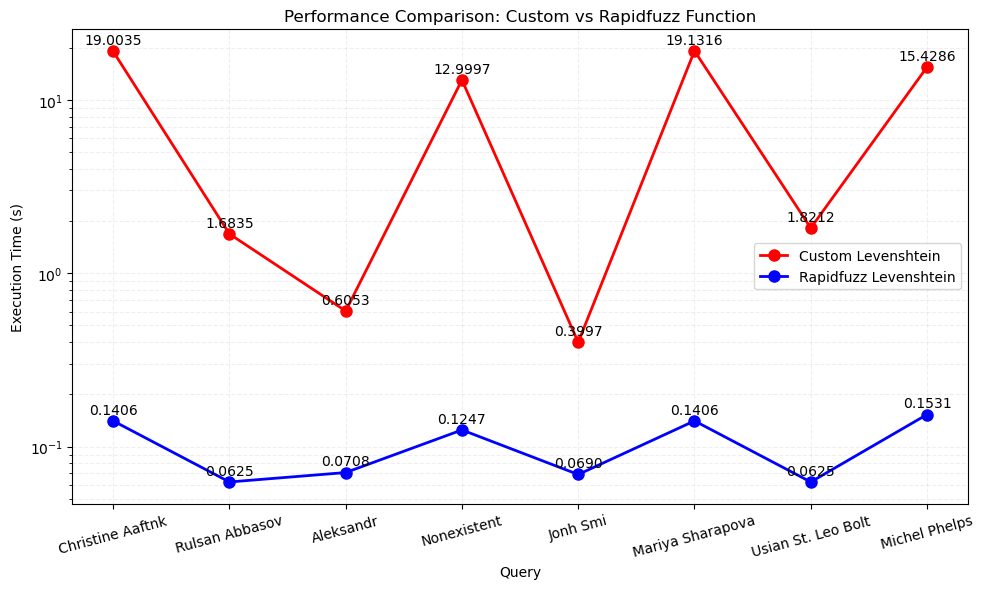

In [12]:
queries, custom_times, rf_times = zip(*timing_data)

plt.figure(figsize=(10, 6))
plt.plot(queries, custom_times, 'r-o', label='Custom Levenshtein', linewidth=2, markersize=8)
plt.plot(queries, rf_times, 'b-o', label='Rapidfuzz Levenshtein', linewidth=2, markersize=8)
plt.title("Performance Comparison: Custom vs Rapidfuzz Function")
plt.xlabel("Query")
plt.ylabel("Execution Time (s)")
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.2)
plt.legend()
plt.xticks(rotation=15)
for i, (ct, rt) in enumerate(zip(custom_times, rf_times)):
    plt.text(i, ct * 1.1, f"{ct:.4f}", ha='center', color='black')
    plt.text(i, rt * 1.1, f"{rt:.4f}", ha='center', color='black')
plt.tight_layout()
plt.show()

`The distance difference between Query and Real data directly affects searching time. And as you see, Rapidfuzz is faster than our custom implementaion, because it uses C in backend.`

### Thanks for attention.